In [1]:
import pandas as pd

# Filenames (these are the original Kaggle filenames)
train_file = "fraudTrain.csv"
test_file = "fraudTest.csv"

# Load with date parsing for convenience
train = pd.read_csv(train_file, parse_dates=["trans_date_trans_time", "dob"], low_memory=False)
test = pd.read_csv(test_file, parse_dates=["trans_date_trans_time", "dob"], low_memory=False)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.columns

Train shape: (1296675, 23)
Test shape: (555719, 23)


Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [3]:
train.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [5]:
test.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [7]:
# Number of duplicate rows
print(train.duplicated().sum(),test.duplicated().sum())

0 0


In [9]:
train.describe().T

,count,mean,min,25%,50%,75%,max,std
Unnamed: 0,1296675.0,648337.0,0.0,324168.5,648337.0,972505.5,1296674.0,374317.974488
trans_date_trans_time,1296675,2019-10-03 12:47:28.070214144,2019-01-01 00:00:18,2019-06-03 19:12:22.500000,2019-10-03 07:35:47,2020-01-28 15:02:55.500000,2020-06-21 12:13:37,NaN
cc_num,1296675.0,417192042079726656.0,60416207185.0,180042946491150.0,3521417320836166.0,4642255475285942.0,4992346398065154048.0,1308806447000789248.0
amt,1296675.0,70.351035,1.0,9.65,47.52,83.14,28948.9,160.316039
zip,1296675.0,48800.671097,1257.0,26237.0,48174.0,72042.0,99783.0,26893.222476
lat,1296675.0,38.537622,20.0271,34.6205,39.3543,41.9404,66.6933,5.075808
long,1296675.0,-90.226335,-165.6723,-96.798,-87.4769,-80.158,-67.9503,13.759077
city_pop,1296675.0,88824.440563,23.0,743.0,2456.0,20328.0,2906700.0,301956.360689
dob,1296675,1973-10-03 19:02:55.017178512,1924-10-30 00:00:00,1962-08-13 00:00:00,1975-11-30 00:00:00,1987-02-22 00:00:00,2005-01-29 00:00:00,NaN
unix_time,1296675.0,1349243636.726123,1325376018.0,1338750742.5,1349249747.0,1359385375.5,1371816817.0,12841278.42336


In [11]:
train.dtypes

Unnamed: 0                        int64
trans_date_trans_time    datetime64[ns]
cc_num                            int64
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
gender                           object
street                           object
city                             object
state                            object
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                      datetime64[ns]
trans_num                        object
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
dtype: object

In [13]:
train['zip'].value_counts()

zip
73754    3646
34112    3613
48088    3597
82514    3527
49628    3123
         ... 
46510       7
16041       7
38915       7
10018       7
23523       7
Name: count, Length: 970, dtype: int64

In [15]:
# Automatically detect object / string columns (categorical)
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", categorical_cols)

Categorical Columns: ['merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'trans_num']


In [17]:
for col in categorical_cols:
    print(f"{col}: {train[col].nunique()} unique values")

merchant: 693 unique values
category: 14 unique values
first: 352 unique values
last: 481 unique values
gender: 2 unique values
street: 983 unique values
city: 894 unique values
state: 51 unique values
job: 494 unique values
trans_num: 1296675 unique values


In [18]:
train['category'].value_counts()

category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: count, dtype: int64

In [21]:
for col in categorical_cols:
    top_freq = train[col].value_counts(normalize=True).values[0]
    print(f"{col} → Dominant category frequency: {top_freq:.2%}")

merchant → Dominant category frequency: 0.34%
category → Dominant category frequency: 10.15%
first → Dominant category frequency: 2.06%
last → Dominant category frequency: 2.22%
gender → Dominant category frequency: 54.74%
street → Dominant category frequency: 0.24%
city → Dominant category frequency: 0.43%
state → Dominant category frequency: 7.32%
job → Dominant category frequency: 0.75%
trans_num → Dominant category frequency: 0.00%


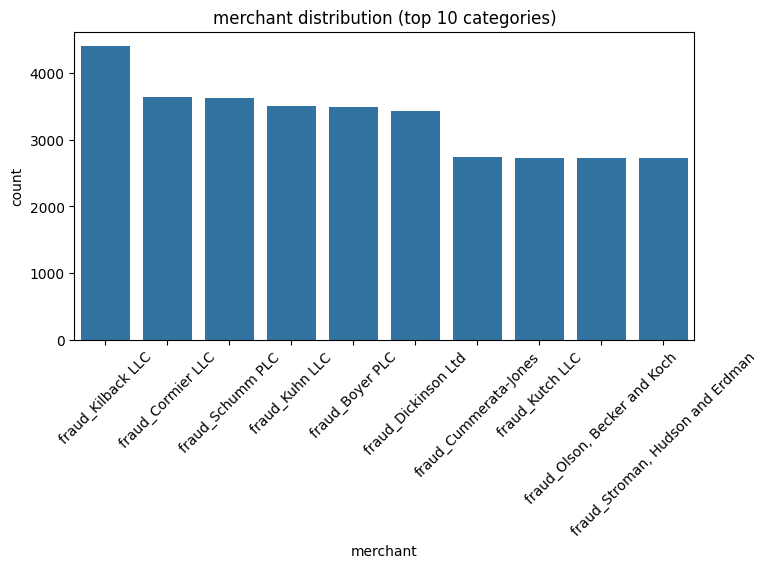

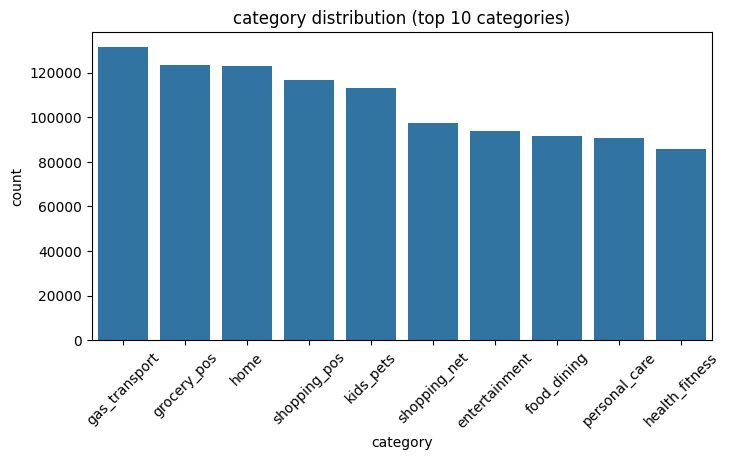

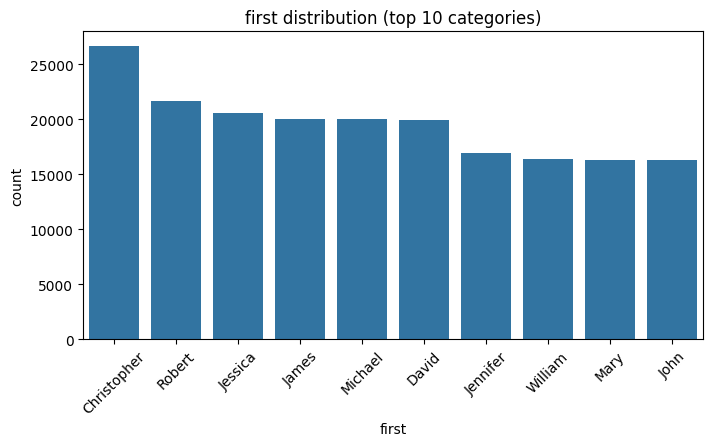

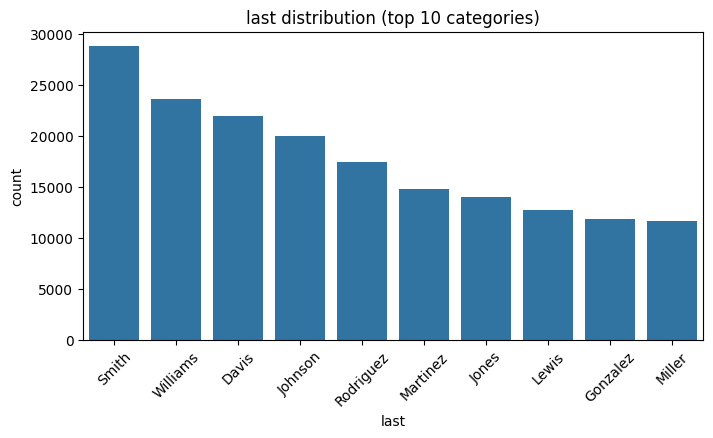

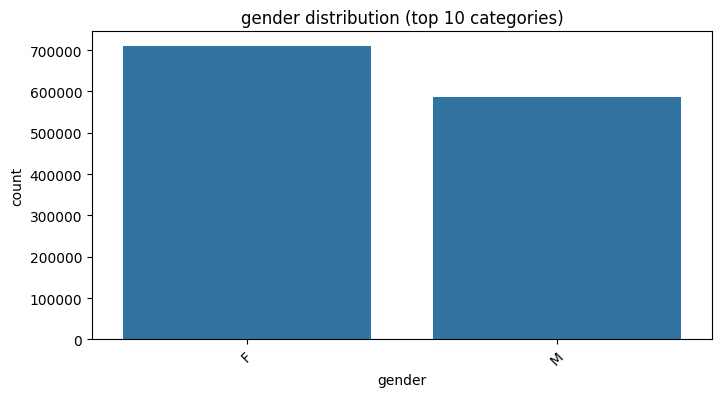

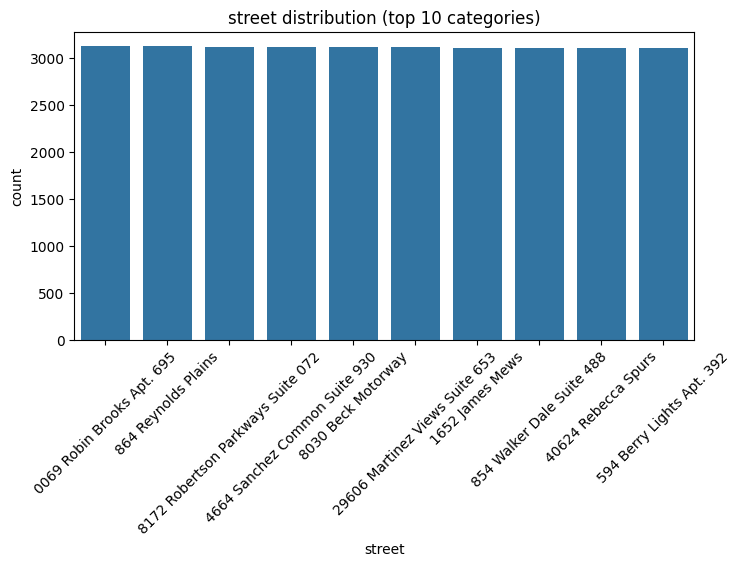

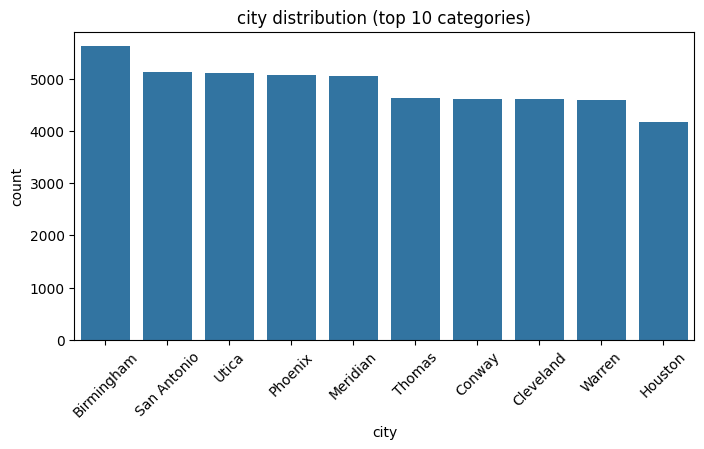

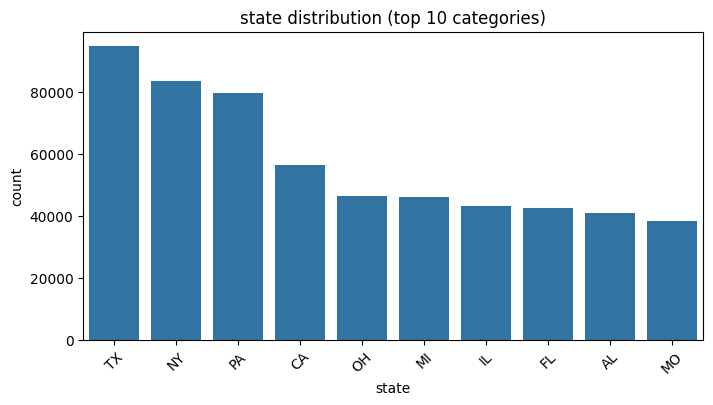

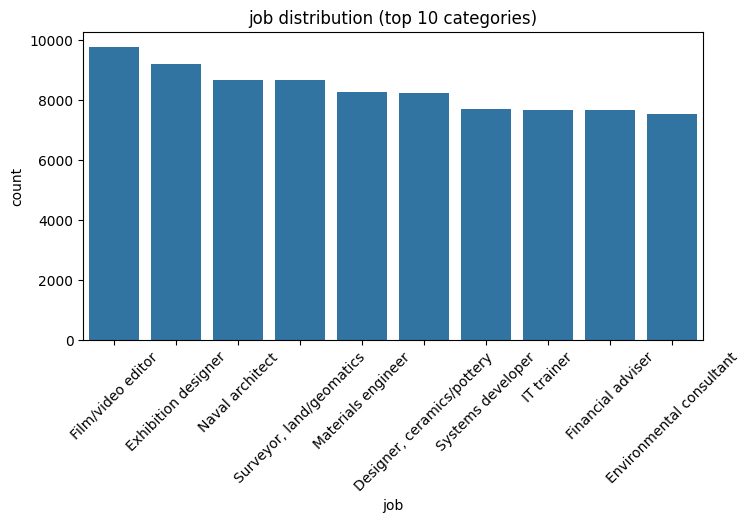

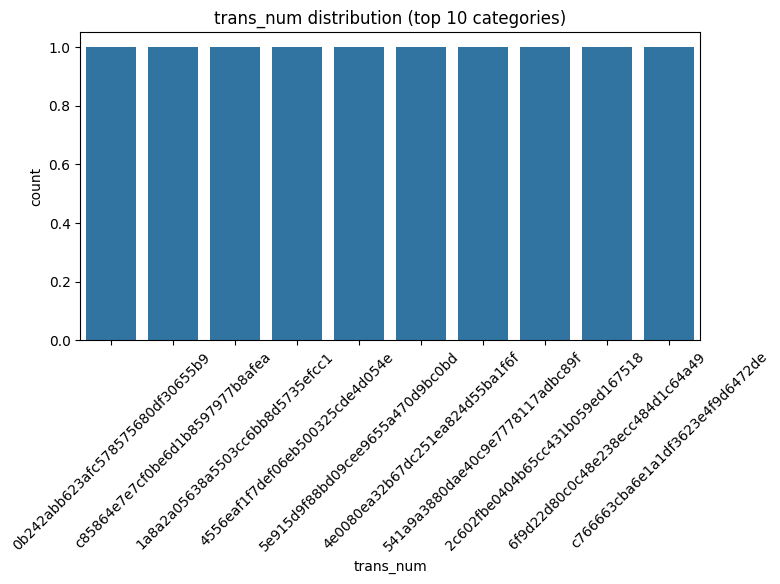

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=train, x=col, order=train[col].value_counts().iloc[:10].index)
    plt.title(f"{col} distribution (top 10 categories)")
    plt.xticks(rotation=45)
    plt.show()

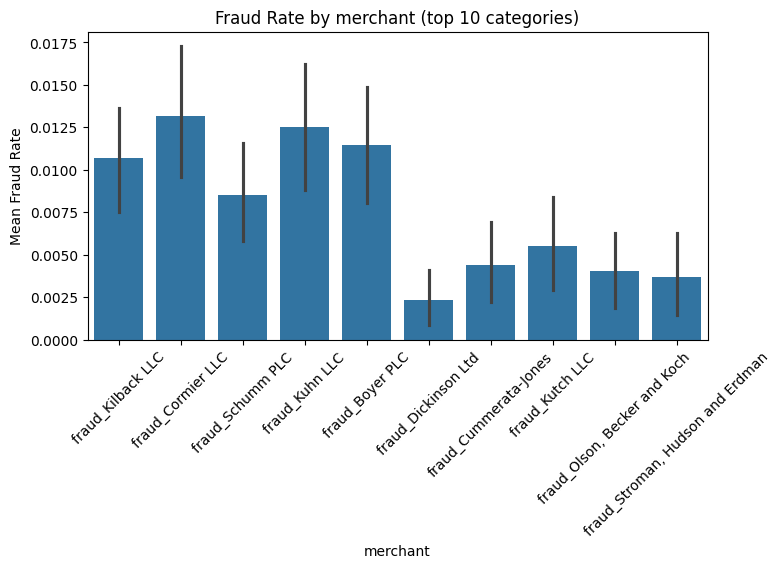

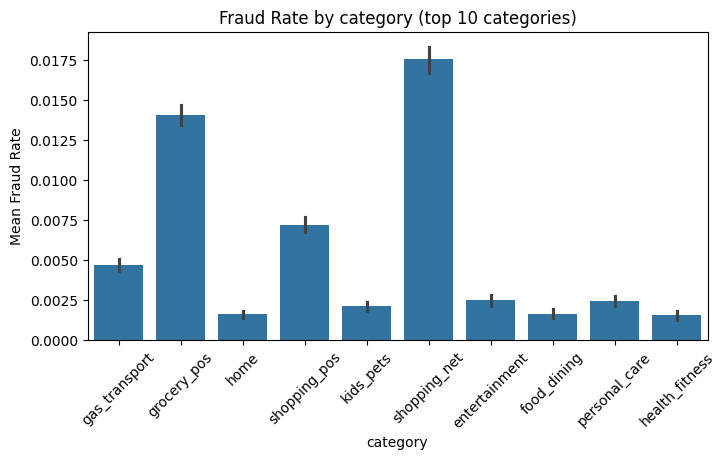

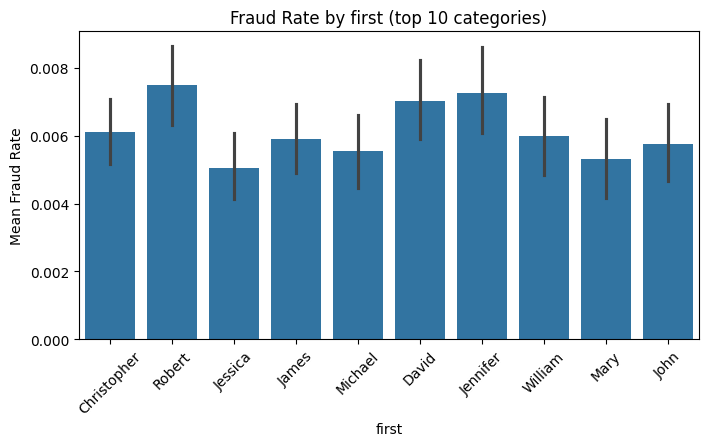

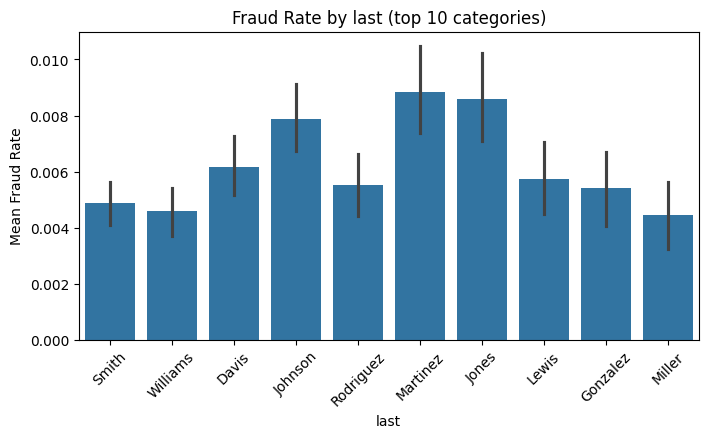

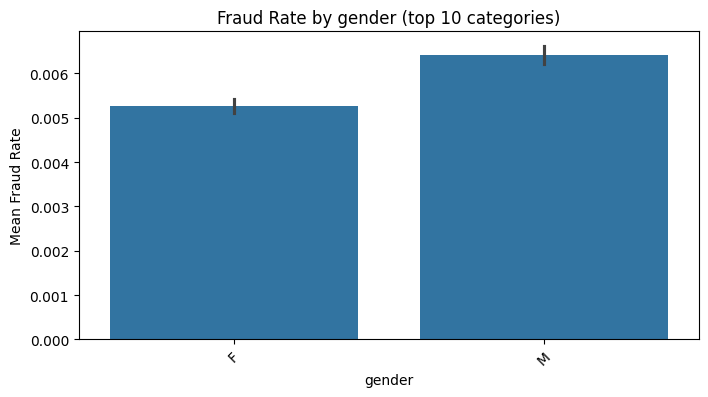

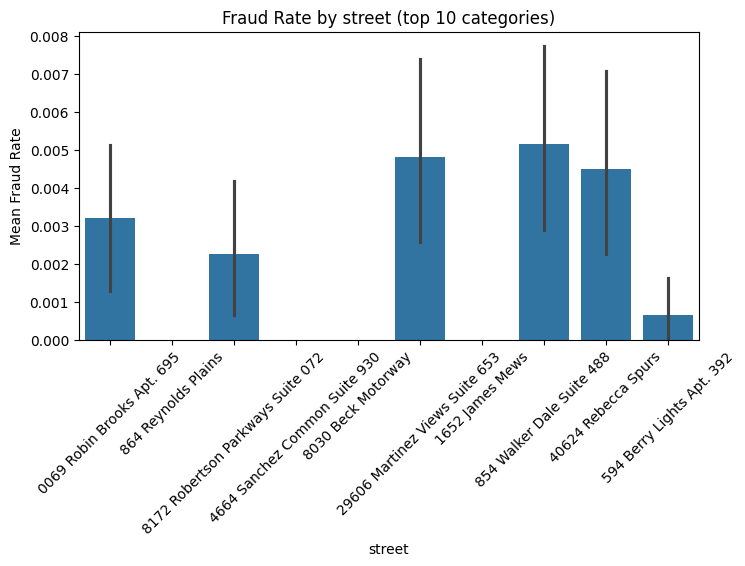

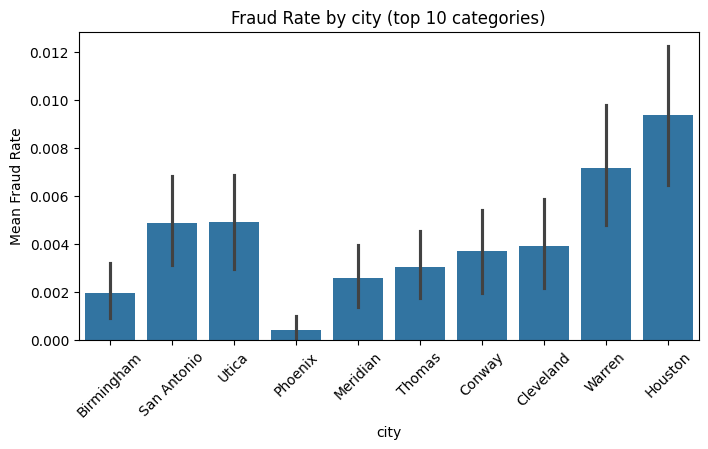

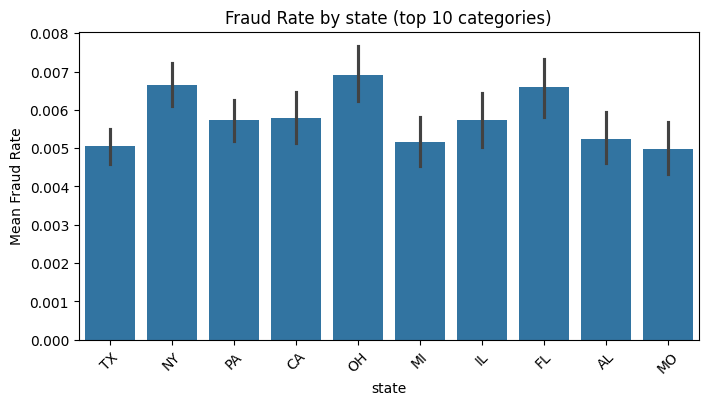

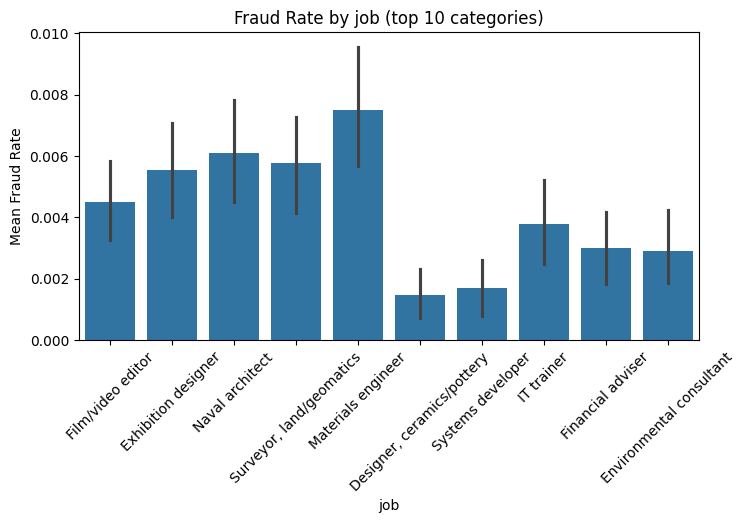

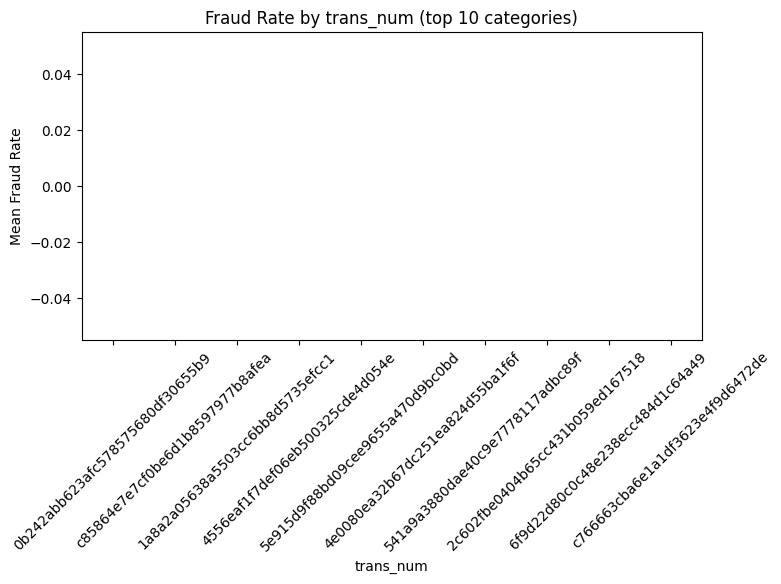

In [24]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.barplot(x=col, y='is_fraud', data=train,
                order=train[col].value_counts().iloc[:10].index)
    plt.title(f"Fraud Rate by {col} (top 10 categories)")
    plt.xticks(rotation=45)
    plt.ylabel("Mean Fraud Rate")
    plt.show()

In [25]:
city_state_counts = (
    train.groupby("city")["state"]
         .nunique()
)

if (city_state_counts > 1).any():
    print("Yes, this dataset contains same city name for multiple states.")
else:
    print("All city–state combinations are unique.")

Yes, this dataset contains same city name for multiple states.


In [26]:
duplicate_cities = city_state_counts[city_state_counts > 1]

print("Cities appearing in multiple states:")
print(duplicate_cities)


Cities appearing in multiple states:
city
Afton          2
Allentown      3
Andrews        2
Arcadia        3
Bay City       2
Benton         2
Birmingham     2
Brandon        2
Burbank        2
Camden         3
Clarksville    2
Cleveland      2
Conway         2
Fulton         2
Georgetown     2
Hampton        2
Hudson         2
Irvine         2
Meadville      2
Meridian       2
Mesa           2
Norwalk        2
Oakland        2
Orient         2
Randolph       2
Springfield    2
Summerfield    2
Thomas         2
Utica          3
Warren         2
Name: state, dtype: int64


In [27]:
def add_time_features(df):
    df = df.sort_values(["cc_num", "trans_date_trans_time"]).copy()

    # Month
    df["month"] = df["trans_date_trans_time"].dt.month

    # Day of month
    df["day"] = df["trans_date_trans_time"].dt.day

    # Part of day
    def get_part_of_day(hour):
        if 5 <= hour < 12:
            return "morning"
        elif 12 <= hour < 17:
            return "afternoon"
        elif 17 <= hour < 21:
            return "evening"
        else:
            return "night"

    df["part_of_day"] = df["trans_date_trans_time"].dt.hour.apply(get_part_of_day)

    # Time since previous transaction (per card)
    df["time_since_last"] = (
        df.groupby("cc_num")["trans_date_trans_time"]
        .diff()
        .dt.total_seconds()
    )

    df["time_since_last"] = df["time_since_last"].fillna(0)

    return df
train=add_time_features(train)
test=add_time_features(test)

In [28]:
import numpy as np

def preprocess_fraud_data(df):
    """
    Preprocess credit card fraud dataset:
    - Drop Unnamed: 0
    - Convert cc_num to string
    - Compute age from dob and drop dob
    - Compute distance between customer and merchant
    - Drop raw lat/long columns
    """
    df = df.copy()
    
    # 1. Drop Unnamed: 0 if exists
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])
    
    # 2. Drop cc_num if exists
    if "cc_num" in df.columns:
        df = df.drop(columns=["cc_num"])
    
    # 3. Drop first if exists
    if "first" in df.columns:
        df = df.drop(columns=["first"])

    # 4. Drop last if exists
    if "last" in df.columns:
        df = df.drop(columns=["last"])

    # 5. Drop street if exists
    if "street" in df.columns:
        df = df.drop(columns=["street"])

    # 6. Drop city if exists
    if "city" in df.columns:
        df = df.drop(columns=["city"])

    # 7. Drop trans_num if exists
    if "trans_num" in df.columns:
        df = df.drop(columns=["trans_num"])
    
    # 8. Compute age and drop dob
    if "dob" in df.columns and "trans_date_trans_time" in df.columns:
        df["age"] = (df["trans_date_trans_time"] - df["dob"]).dt.days // 365
        df = df.drop(columns=["dob"])

    # 9. Drop trans_date_trans_time if exists
    if "trans_date_trans_time" in df.columns:
        df = df.drop(columns=["trans_date_trans_time"])

    # 10. Drop dob if exists
    if "trans_date_trans_time" in df.columns:
        df = df.drop(columns=["dob"])
    
    # 11. Compute distance using Haversine formula
    coord_cols = ["lat", "long", "merch_lat", "merch_long"]
    if all(col in df.columns for col in coord_cols):
        def haversine(lat1, lon1, lat2, lon2):
            R = 6371  # Earth radius in km
            lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
            dlat = lat2 - lat1
            dlon = lon2 - lon1
            a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
            c = 2 * np.arcsin(np.sqrt(a))
            return R * c
        
        df["distance"] = haversine(df["lat"], df["long"], df["merch_lat"], df["merch_long"])
        
        # Drop raw coordinates
        df = df.drop(columns=coord_cols)
    
    return df

In [29]:
test.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'month', 'day', 'part_of_day',
       'time_since_last'],
      dtype='object')

In [30]:
train_preprocessed=preprocess_fraud_data(train)
test_preprocessed=preprocess_fraud_data(test)

In [31]:
train_preprocessed.head()

,merchant,category,amt,gender,state,zip,city_pop,job,unix_time,is_fraud,month,day,part_of_day,time_since_last,age,distance
1017,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,F,WY,82514,1645,Information systems manager,1325422035,0,1,1,afternoon,0.0,32,127.606239
2724,fraud_Berge LLC,gas_transport,52.94,F,WY,82514,1645,Information systems manager,1325493897,0,1,2,morning,71862.0,32,110.308921
2726,fraud_Luettgen PLC,gas_transport,82.08,F,WY,82514,1645,Information systems manager,1325494056,0,1,2,morning,159.0,32,21.787261
2882,fraud_Daugherty LLC,kids_pets,34.79,F,WY,82514,1645,Information systems manager,1325507894,0,1,2,afternoon,13838.0,32,87.204215
2907,fraud_Beier and Sons,home,27.18,F,WY,82514,1645,Information systems manager,1325509846,0,1,2,afternoon,1952.0,32,74.212965


In [32]:
train_preprocessed.columns

Index(['merchant', 'category', 'amt', 'gender', 'state', 'zip', 'city_pop',
       'job', 'unix_time', 'is_fraud', 'month', 'day', 'part_of_day',
       'time_since_last', 'age', 'distance'],
      dtype='object')

In [33]:
test_preprocessed.columns

Index(['merchant', 'category', 'amt', 'gender', 'state', 'zip', 'city_pop',
       'job', 'unix_time', 'is_fraud', 'month', 'day', 'part_of_day',
       'time_since_last', 'age', 'distance'],
      dtype='object')

In [35]:
test_preprocessed['is_fraud'].value_counts()

is_fraud
0    553574
1      2145
Name: count, dtype: int64

In [47]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, recall_score

# -------------------------------
# 1. Define categorical features
# -------------------------------
cat_cols = ["merchant", "category", "gender", "state", "job", "part_of_day"]

# -------------------------------
# 2. Split data
# -------------------------------
X = train_preprocessed.drop("is_fraud", axis=1)
y = train_preprocessed["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------------
# 3. Initialize CatBoost
# -------------------------------
model = CatBoostClassifier(
    iterations=600,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="Recall",  # optimize for recall during training
    scale_pos_weight=20,   # handle imbalance (adjust later if needed)
    random_seed=42,
    verbose=False,
)

# -------------------------------
# 4. Train model
# -------------------------------
model.fit(
    X_train,
    y_train,
    cat_features=cat_cols,
    eval_set=(X_test, y_test),
    use_best_model=True,
)

# -------------------------------
# 5. Predictions
# -------------------------------
y_pred = model.predict(X_test)

# -------------------------------
# 6. Metrics: Recall & F1
# -------------------------------
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Recall:", recall)
print("F1 Score:", f1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Recall: 0.9560293137908061
F1 Score: 0.8433734939759037

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.75      0.96      0.84      1501

    accuracy                           1.00    259335
   macro avg       0.88      0.98      0.92    259335
weighted avg       1.00      1.00      1.00    259335



In [48]:
X_testing = test_preprocessed.drop("is_fraud", axis=1)
y_testing = test_preprocessed["is_fraud"]
# Prediction
y_predict = model.predict(X_testing)
# metric calculation
recall = recall_score(y_testing, y_predict)
f1 = f1_score(y_testing, y_predict)

print("Recall:", recall)
print("F1 Score:", f1)
print("\nClassification Report:")
print(classification_report(y_testing, y_predict))

Recall: 0.7132867132867133
F1 Score: 0.7324078506462423

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.75      0.71      0.73      2145

    accuracy                           1.00    555719
   macro avg       0.88      0.86      0.87    555719
weighted avg       1.00      1.00      1.00    555719



In [49]:
train_preprocessed.dtypes

merchant            object
category            object
amt                float64
gender              object
state               object
zip                  int64
city_pop             int64
job                 object
unix_time            int64
is_fraud             int64
month                int32
day                  int32
part_of_day         object
time_since_last    float64
age                  int64
distance           float64
dtype: object

In [50]:
train_preprocessed.nunique()

merchant               693
category                14
amt                  52928
gender                   2
state                   51
zip                    970
city_pop               879
job                    494
unix_time          1274823
is_fraud                 2
month                   12
day                     31
part_of_day              4
time_since_last     159132
age                     83
distance           1296675
dtype: int64

In [51]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, classification_report
from category_encoders import TargetEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ---------------------------
# Columns
# ---------------------------
target = "is_fraud"

low_card = ["gender", "part_of_day", "category"]
high_card = ["merchant", "state", "job", "zip"]

X = train_preprocessed.drop(columns=[target])
y = train_preprocessed[target]

# ---------------------------
# Preprocessing pipeline
# ---------------------------

preprocess = ColumnTransformer(
    transformers=[
        ("target_enc", TargetEncoder(), high_card),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), low_card),
    ],
    remainder="passthrough"
)

# ---------------------------
# XGBoost model
# ---------------------------

# compute imbalance weight
scale_pos_weight = (len(y) - sum(y)) / sum(y)

model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
)

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

# ---------------------------
# Train-test split
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---------------------------
# Train
# ---------------------------

pipeline.fit(X_train, y_train)

# ---------------------------
# Predict
# ---------------------------

y_pred = pipeline.predict(X_test)

# ---------------------------
# Metrics
# ---------------------------

print("F1 Score:", f1_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred))

F1 Score: 0.5783664459161147
Recall: 0.9600266489007329

Detailed Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    257834
           1       0.41      0.96      0.58      1501

    accuracy                           0.99    259335
   macro avg       0.71      0.98      0.79    259335
weighted avg       1.00      0.99      0.99    259335



In [52]:
X_testing = test_preprocessed.drop("is_fraud", axis=1)
y_testing = test_preprocessed["is_fraud"]
# Prediction
y_predict = pipeline.predict(X_testing)
# metric calculation
recall = recall_score(y_testing, y_predict)
f1 = f1_score(y_testing, y_predict)

print("Recall:", recall)
print("F1 Score:", f1)
print("\nClassification Report:")
print(classification_report(y_testing, y_predict))

Recall: 0.6806526806526807
F1 Score: 0.3920515574650913

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.28      0.68      0.39      2145

    accuracy                           0.99    555719
   macro avg       0.64      0.84      0.69    555719
weighted avg       1.00      0.99      0.99    555719



# CatBoost model is better